In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("20-digitalskysurvey.csv")

In [3]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


In [6]:
df.describe()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.237650e+18,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,1.645022e+18,0.143726,1460.986400,52943.533300,353.069400
std,0.000000e+00,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,2.013998e+18,0.388774,1788.778371,1511.150651,206.298149
min,1.237650e+18,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,2.995780e+17,-0.004136,266.000000,51578.000000,1.000000
25%,1.237650e+18,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,3.389248e+17,0.000081,301.000000,51900.000000,186.750000
50%,1.237650e+18,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,4.966580e+17,0.042591,441.000000,51997.000000,351.000000
75%,1.237650e+18,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,2.881300e+18,0.092579,2559.000000,54468.000000,510.000000
max,1.237650e+18,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,9.468830e+18,5.353854,8410.000000,57481.000000,1000.000000


In [7]:
df.columns

Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')

In [8]:
df.isna().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64

In [13]:
df.duplicated().sum()

0

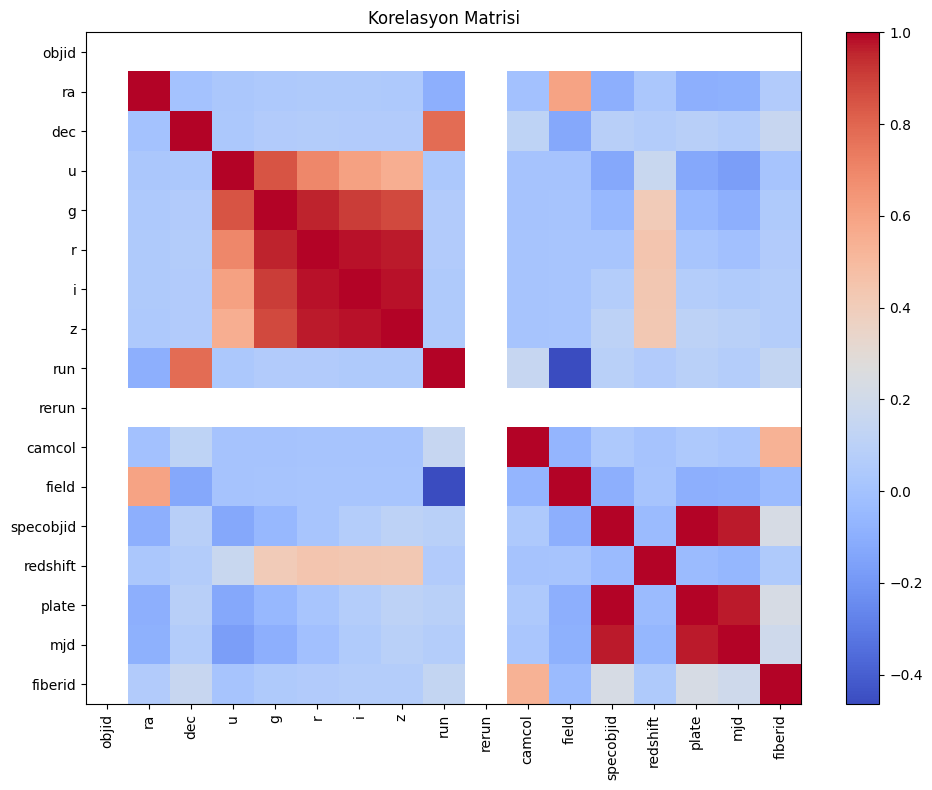

In [14]:

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

In [18]:
columns_to_drop = ["objid","specobjid","rerun","camcol","field","run"]

In [19]:
df.drop(columns_to_drop, axis = 1, inplace=True)

In [20]:
df['class'].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

In [21]:
df["class"].value_counts(normalize=True).mul(100).round(2)

class
GALAXY    49.98
STAR      41.52
QSO        8.50
Name: proportion, dtype: float64

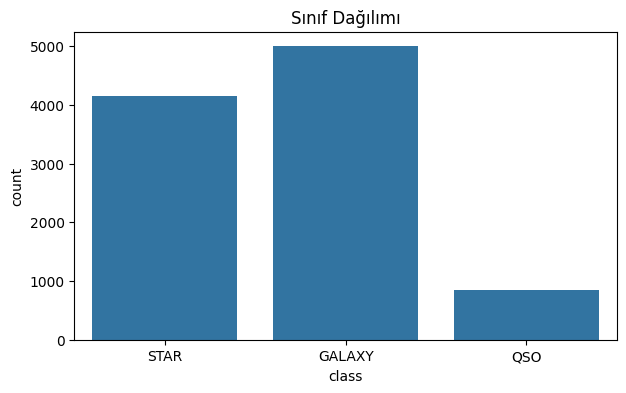

In [22]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="class")
plt.title("Sınıf Dağılımı")
plt.show()

In [23]:
column_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "nunique": df.nunique(),
    "missing": df.isna().sum()
})

column_summary

,dtype,nunique,missing
ra,float64,10000,0
dec,float64,10000,0
u,float64,9730,0
g,float64,9817,0
r,float64,9852,0
i,float64,9890,0
z,float64,9896,0
class,object,3,0
redshift,float64,9637,0
plate,int64,487,0


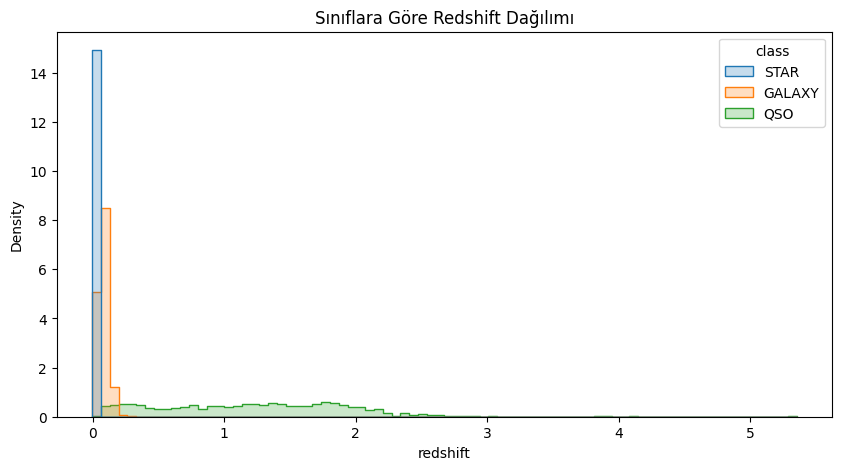

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="redshift",
    hue="class",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Sınıflara Göre Redshift Dağılımı")
plt.show()

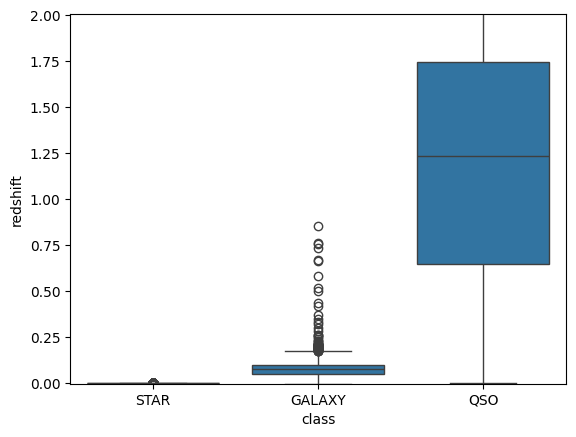

In [25]:
sns.boxplot(data=df, x="class", y="redshift")
plt.ylim(df["redshift"].quantile(0.001),
         df["redshift"].quantile(0.99))
plt.show()

In [28]:
df.groupby("class")[
    ["u", "g", "r", "i", "z", "redshift"]
].agg(["min", "median", "mean", "max"])

u                                         g             \
             min     median       mean       max       min     median   
class                                                                   
GALAXY  14.45856  18.988990  18.804339  19.59990  13.08055  17.496555   
QSO     15.92846  19.088800  18.942928  19.59975  15.75834  18.822220   
STAR    12.98897  18.500935  18.330439  19.59934  12.79955  17.237445   

                                    r             ...          i            \
             mean       max       min     median  ...       mean       max   
class                                             ...                        
GALAXY  17.350216  19.68232  12.43160  16.741390  ...  16.272770  24.36181   
QSO     18.678714  19.73869  15.35982  18.659365  ...  18.360007  20.01105   
STAR    17.130547  19.91897  12.48238  16.788435  ...  16.594047  28.17963   

               z                                  redshift            \
             min     median       mean       max       min    median   
class                                                                  
GALAXY  11.61041  16.073810  16.017923  22.83306 -0.000513  0.077330   
QSO     14.51594  18.457200  18.274761  20.44429  0.000461  1.234131   
STAR    12.60718  16.548885  16.531119  20.79610 -0.004136  0.000024   

                            
            mean       max  
class                       
GALAXY  0.080325  0.855881  
QSO     1.218366  5.353854  
STAR    0.000043  0.004563  

[3 rows x 24 columns]

In [29]:
df.groupby("class")["redshift"].quantile(
    [0.01, 0.25, 0.50, 0.75, 0.99]
)

class       
GALAXY  0.01    0.007534
        0.25    0.051216
        0.50    0.077330
        0.75    0.101164
        0.99    0.193228
QSO     0.01    0.082755
        0.25    0.651192
        0.50    1.234131
        0.75    1.744641
        0.99    2.768358
STAR    0.01   -0.000973
        0.25   -0.000133
        0.50    0.000024
        0.75    0.000218
        0.99    0.001095
Name: redshift, dtype: float64

In [30]:
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]

In [34]:
df["u_r"] = df["u"] - df["r"]
df["g_i"] = df["g"] - df["i"]
df["r_z"] = df["r"] - df["z"]
df["u_z"] = df["u"] - df["z"]

In [35]:
color_features = [
    "u_g",
    "g_r",
    "r_i",
    "i_z",
    "u_r",
    "g_i",
    "r_z",
    "u_z"
]

df.groupby("class")[color_features].agg(
    ["mean", "median", "std"]
)

u_g                           g_r                           r_i  \
           mean    median       std      mean    median       std      mean   
class                                                                         
0      1.454123  1.405200  0.367639  0.700710  0.723965  0.243536  0.376736   
1      0.264214  0.212595  0.268068  0.180179  0.145650  0.209508  0.138528   
2      1.199892  1.174510  0.415774  0.398454  0.423840  0.286281  0.138046   

                                i_z  ...       u_r       g_i            \
         median       std      mean  ...       std      mean    median   
class                                ...                                 
0      0.397580  0.112748  0.254847  ...  0.584183  1.077446  1.122090   
1      0.128365  0.158195  0.085246  ...  0.409233  0.318707  0.265115   
2      0.160130  0.299400  0.062928  ...  0.660674  0.536500  0.589730   

                      r_z                           u_z                      
            std      mean    median       std      mean    median       std  
class                                                                        
0      0.323800  0.631583  0.673875  0.199563  2.786416  2.800785  0.746338  
1      0.309372  0.223774  0.206465  0.253553  0.668167  0.541690  0.567835  
2      0.468328  0.200974  0.221040  0.252932  1.799319  1.776840  0.837063  

[3 rows x 24 columns]

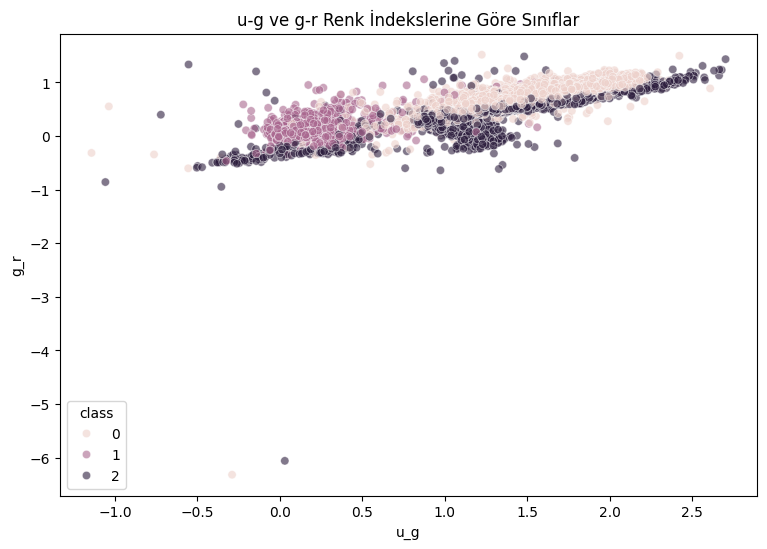

In [36]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="u_g",
    y="g_r",
    hue="class",
    alpha=0.6
)

plt.title("u-g ve g-r Renk İndekslerine Göre Sınıflar")
plt.show()

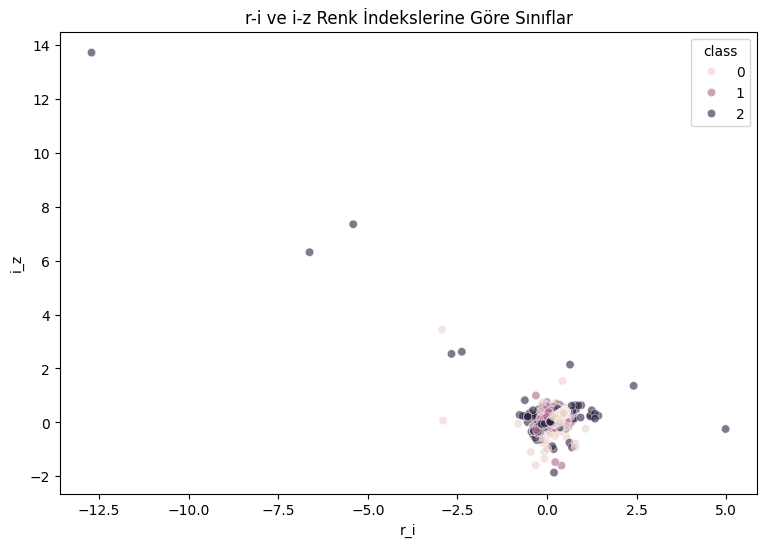

In [37]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="r_i",
    y="i_z",
    hue="class",
    alpha=0.6
)

plt.title("r-i ve i-z Renk İndekslerine Göre Sınıflar")
plt.show()

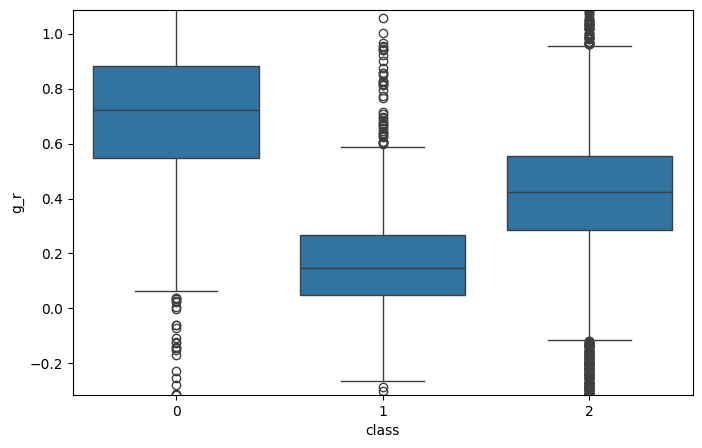

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="class", y="g_r")

lower = df["g_r"].quantile(0.01)
upper = df["g_r"].quantile(0.99)

plt.ylim(lower, upper)
plt.show()

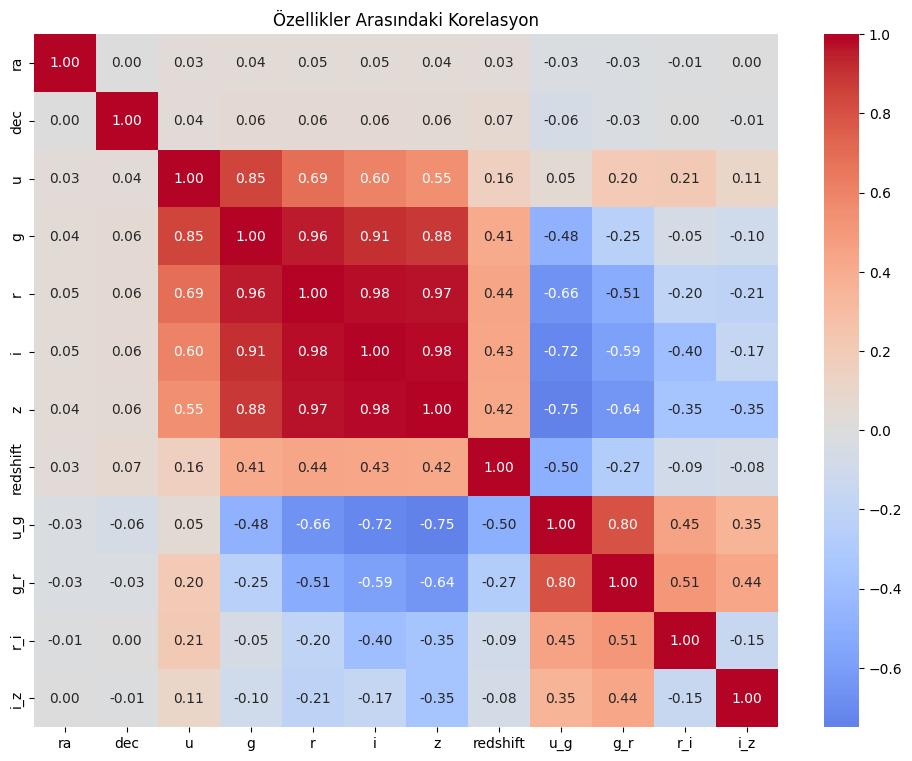

In [40]:
analysis_columns = [
    "ra",
    "dec",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift",
    "u_g",
    "g_r",
    "r_i",
    "i_z"
]

correlation = df[analysis_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Özellikler Arasındaki Korelasyon")
plt.show()

In [45]:
# label encoder

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["class"] = le.fit_transform(df["class"])

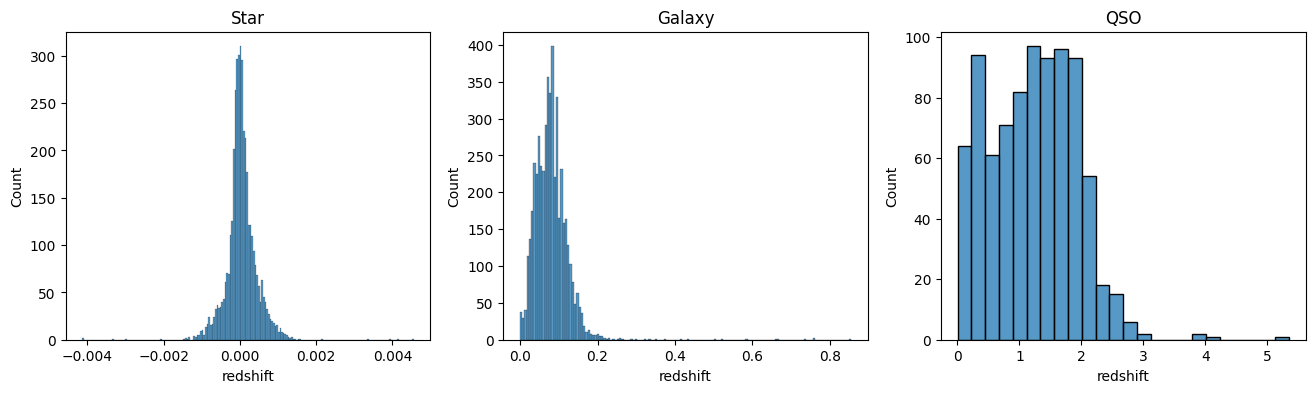

In [41]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(16,4))
ax = sns.histplot(df[df["class"] == 2].redshift, ax = axes[0])
ax.set_title("Star")
ax = sns.histplot(df[df["class"] == 0].redshift, ax = axes[1])
ax.set_title("Galaxy")
ax = sns.histplot(df[df["class"] == 1].redshift, ax = axes[2])
ax.set_title("QSO")
plt.show()

In [42]:
# model

In [43]:
X = df.drop("class", axis=1)
y = df["class"]

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 15)

In [47]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [49]:
from xgboost import XGBClassifier

In [50]:
xgb = XGBClassifier(n_estimators = 100)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1674   16    2]
 [   6  254    0]
 [   7    1 1340]]
accuracy score:  0.9903030303030304
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1692
           1       0.94      0.98      0.96       260
           2       1.00      0.99      1.00      1348

    accuracy                           0.99      3300
   macro avg       0.98      0.99      0.98      3300
weighted avg       0.99      0.99      0.99      3300



In [53]:
params = {
        "n_estimators" : [100, 200, 300, 500],
        "learning_rate" : [0.01, 0.1],
        "max_depth" : [5,8,12,20,30],
        "colsample_bytree" : [0.3, 0.4, 0.5, 0.8, 1]
}

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
grid = GridSearchCV(estimator= XGBClassifier(), param_grid = params, cv=5, n_jobs = -1)

In [59]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1],
                         'learning_rate': [0.01, 0.1],
                         'max_depth': [5, 8, 12, 20, 30],
                         'n_estimators': [100, 200, 300, 500]})

In [60]:
grid.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 12,
 'n_estimators': 100}

In [61]:
y_pred = grid.predict(X_test)

In [62]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1674   16    2]
 [   6  254    0]
 [   7    1 1340]]
accuracy score:  0.9903030303030304
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1692
           1       0.94      0.98      0.96       260
           2       1.00      0.99      1.00      1348

    accuracy                           0.99      3300
   macro avg       0.98      0.99      0.98      3300
weighted avg       0.99      0.99      0.99      3300

